In [ ]:
import pandas as pd

data1 = pd.read_parquet("../data/final_first.parquet")
data2 = pd.read_parquet("../data/final_second.parquet")

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 기본 설정
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 데이터 경로 설정 (현재 노트북 위치에 맞게 수정 필요 시 수정)
data_dir = '../preprocessed_data' 

print("데이터 로딩 중...")
X_src = np.load(os.path.join(data_dir, 'X_source.npy'))
y_src = np.load(os.path.join(data_dir, 'y_source.npy'), allow_pickle=True)
X_tgt = np.load(os.path.join(data_dir, 'X_target.npy'))
y_tgt = np.load(os.path.join(data_dir, 'y_target.npy'), allow_pickle=True)

# nan 처리 (긴급 처방했던 부분)
X_src = np.nan_to_num(X_src, nan=0.0)
X_tgt = np.nan_to_num(X_tgt, nan=0.0)

print(f"✅ Source Shape: X={X_src.shape}, y={y_src.shape}")
print(f"✅ Target Shape: X={X_tgt.shape}, y={y_tgt.shape}")

데이터 로딩 중...
✅ Source Shape: X=(15375, 2000, 5), y=(15375,)
✅ Target Shape: X=(39648, 2000, 5), y=(39648,)


C:\Users\akska\AppData\Local\Temp\ipykernel_27328\1194833453.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y_src, ax=axes[0], order=np.unique(y_src), palette='Blues_r')
C:\Users\akska\AppData\Local\Temp\ipykernel_27328\1194833453.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y_tgt, ax=axes[1], order=np.unique(y_tgt), palette='Oranges_r')


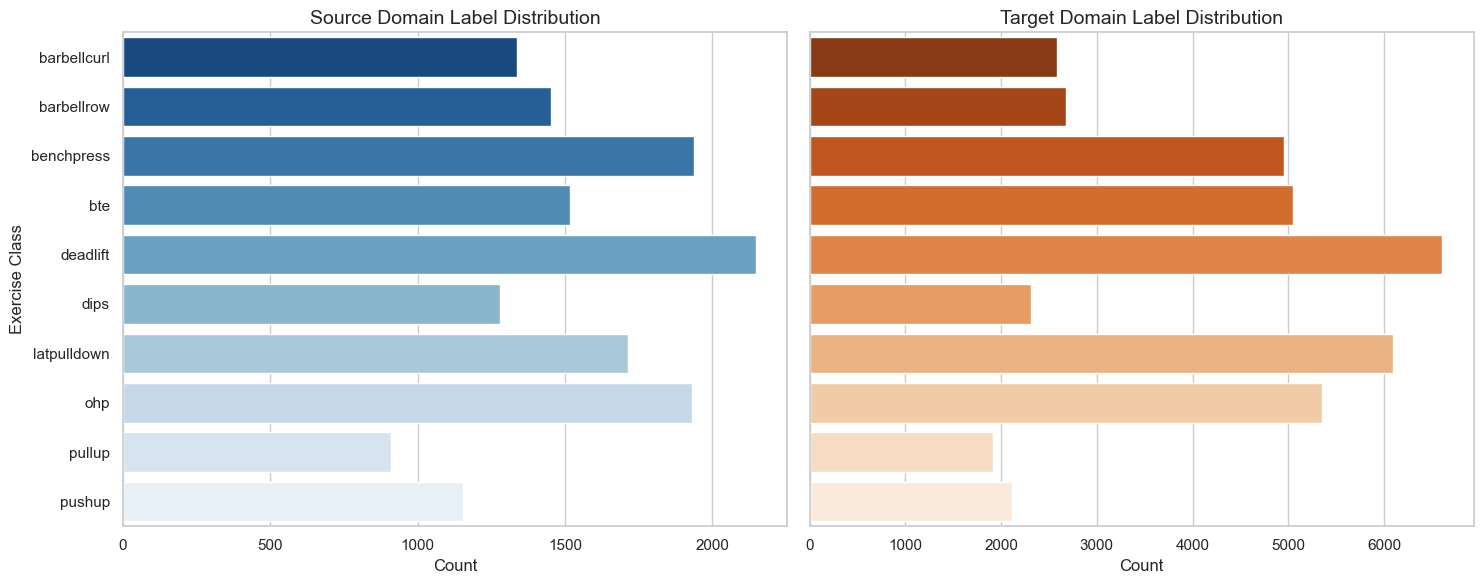

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Source 라벨 분포
sns.countplot(y=y_src, ax=axes[0], order=np.unique(y_src), palette='Blues_r')
axes[0].set_title('Source Domain Label Distribution', fontsize=14)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Exercise Class')

# Target 라벨 분포
sns.countplot(y=y_tgt, ax=axes[1], order=np.unique(y_tgt), palette='Oranges_r')
axes[1].set_title('Target Domain Label Distribution', fontsize=14)
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

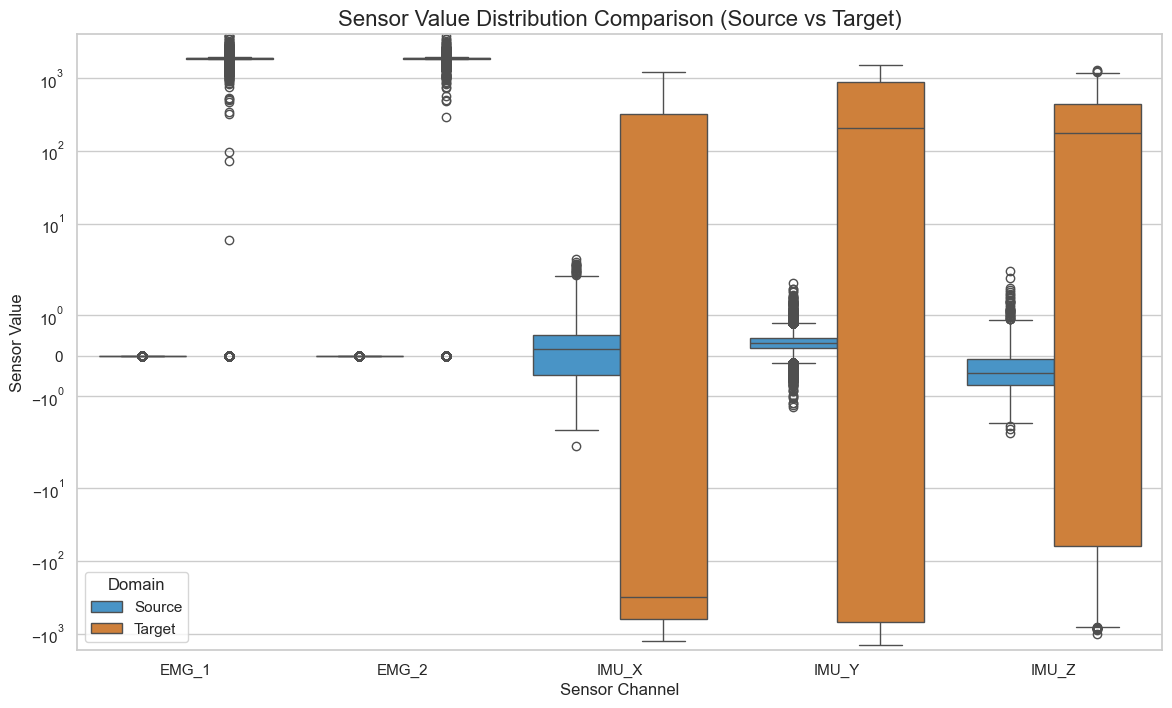

In [4]:
# 채널 이름 (예시: 실험 환경에 맞게 변경)
channel_names = ['EMG_1', 'EMG_2', 'IMU_X', 'IMU_Y', 'IMU_Z']

# 계산을 위해 (N, 2000, 5) -> (N*2000, 5)로 펼치기
# 너무 크면 메모리가 터질 수 있으니 각 도메인에서 랜덤하게 10만 개 포인트만 샘플링
sample_size = 100000

src_flat = X_src.reshape(-1, 5)
tgt_flat = X_tgt.reshape(-1, 5)

np.random.seed(42)
src_sample = src_flat[np.random.choice(src_flat.shape[0], sample_size, replace=False)]
tgt_sample = tgt_flat[np.random.choice(tgt_flat.shape[0], sample_size, replace=False)]

# 시각화를 위해 DataFrame으로 변환
df_src = pd.DataFrame(src_sample, columns=channel_names)
df_src['Domain'] = 'Source'

df_tgt = pd.DataFrame(tgt_sample, columns=channel_names)
df_tgt['Domain'] = 'Target'

df_combined = pd.concat([df_src, df_tgt])
df_melted = df_combined.melt(id_vars='Domain', var_name='Sensor Channel', value_name='Sensor Value')

plt.figure(figsize=(14, 8))
# y축 스케일이 너무 다르면 안 보일 수 있으므로 필요시 symlog 스케일 적용
sns.boxplot(data=df_melted, x='Sensor Channel', y='Sensor Value', hue='Domain', palette=['#3498db', '#e67e22'])
plt.title('Sensor Value Distribution Comparison (Source vs Target)', fontsize=16)
plt.yscale('symlog') # 값 차이가 너무 크면 이 줄의 주석을 해제하세요 (로그 스케일)
plt.show()

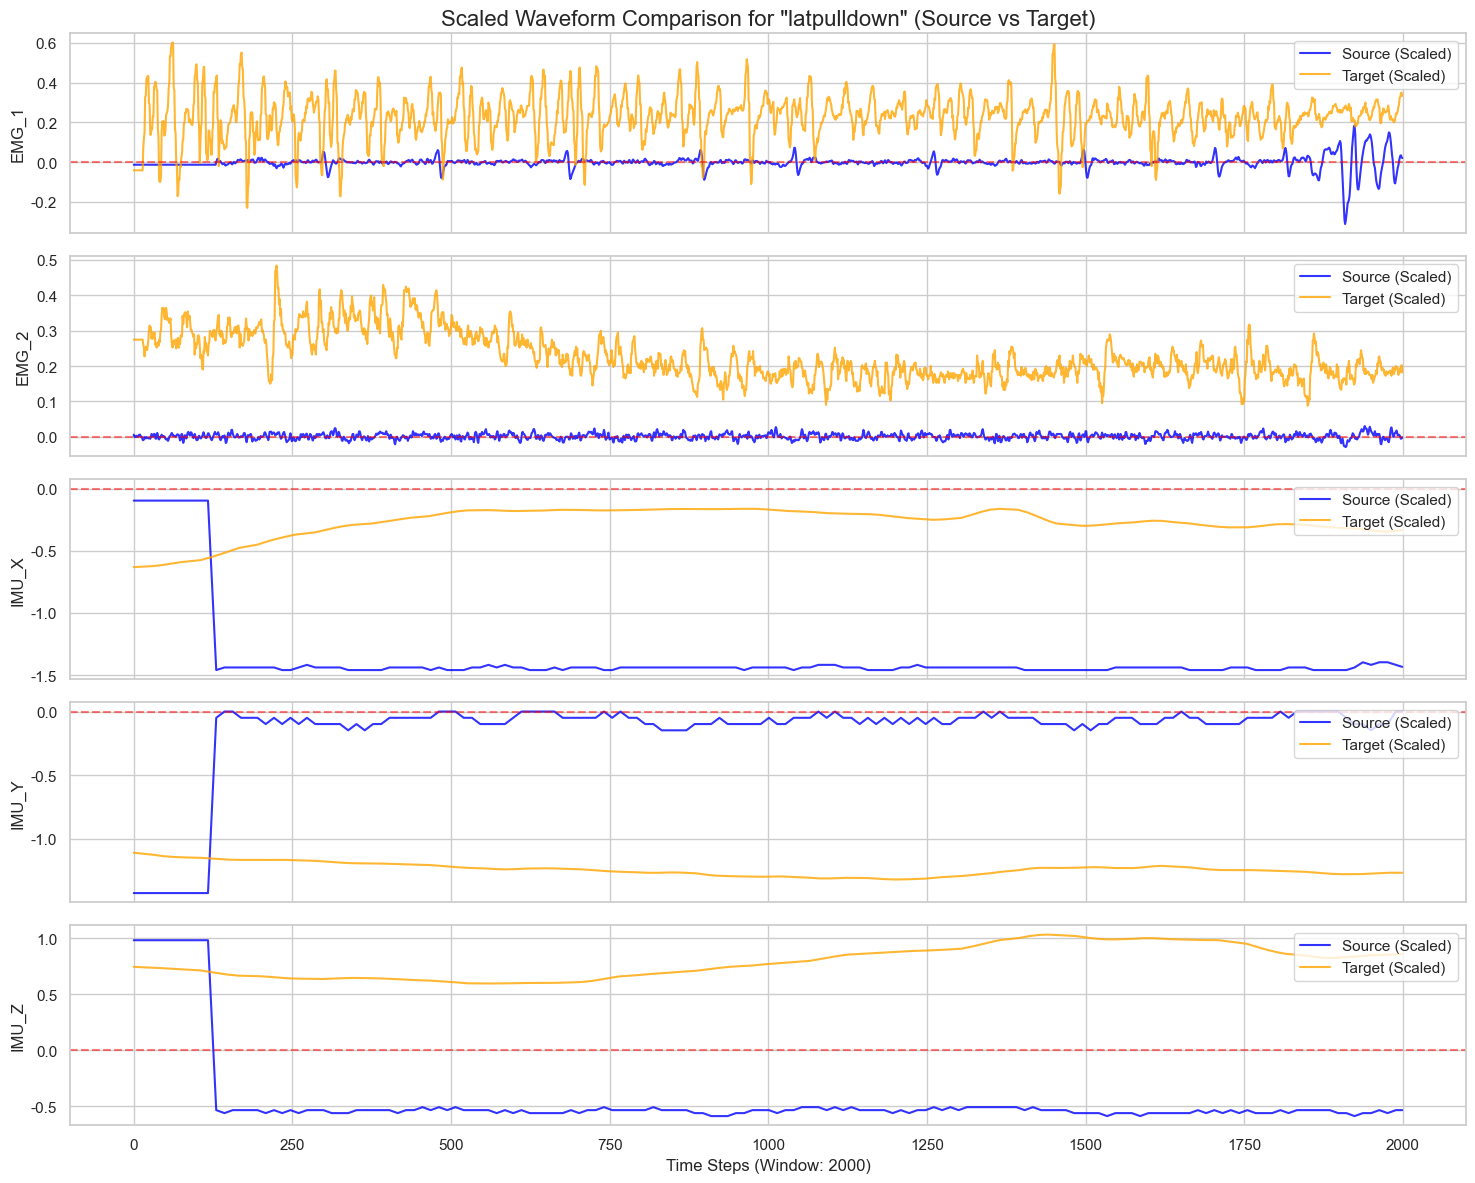

In [9]:
from sklearn.preprocessing import StandardScaler

# 1. 3차원 데이터(N, 2000, 5)를 스케일링하기 위해 2차원으로 펼치기
N_src, L, C = X_src.shape
N_tgt, _, _ = X_tgt.shape

src_flat = X_src.reshape(-1, C)
tgt_flat = X_tgt.reshape(-1, C)

# 2. 도메인 독립적 스케일링 (각각의 평균과 분산으로 0과 1로 맞춤)
scaler_src = StandardScaler()
src_scaled_flat = scaler_src.fit_transform(src_flat)

scaler_tgt = StandardScaler()
tgt_scaled_flat = scaler_tgt.fit_transform(tgt_flat)

# 다시 3차원으로 복구
X_src_scaled = src_scaled_flat.reshape(N_src, L, C)
X_tgt_scaled = tgt_scaled_flat.reshape(N_tgt, L, C)

# ==========================================
# 3. 스케일링 된 파형 시각화
# ==========================================
target_class = 'latpulldown' # 확인하고 싶은 운동 클래스
channel_names = ['EMG_1', 'EMG_2', 'IMU_X', 'IMU_Y', 'IMU_Z']

# 해당 클래스의 첫 번째 샘플 인덱스 찾기
src_idx = np.where(y_src == target_class)[0][0]
tgt_idx = np.where(y_tgt == target_class)[0][0]

src_wave_scaled = X_src_scaled[src_idx] 
tgt_wave_scaled = X_tgt_scaled[tgt_idx] 

fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)

for i in range(5):
    # 스케일이 맞춰졌으므로 겹쳐서 그려도 한눈에 비교가 가능합니다!
    axes[i].plot(src_wave_scaled[:, i], label='Source (Scaled)', color='blue', alpha=0.8, linewidth=1.5)
    axes[i].plot(tgt_wave_scaled[:, i], label='Target (Scaled)', color='orange', alpha=0.8, linewidth=1.5)
    axes[i].set_ylabel(channel_names[i], fontsize=12)
    
    # 0점 기준선 (평균)
    axes[i].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[i].legend(loc='upper right')

axes[0].set_title(f'Scaled Waveform Comparison for "{target_class}" (Source vs Target)', fontsize=16)
axes[-1].set_xlabel('Time Steps (Window: 2000)', fontsize=12)
plt.tight_layout()
plt.show()

식별자(Subject/File info) 로딩 중...
✅ 식별자 로드 완료: Source(15375개), Target(39648개)


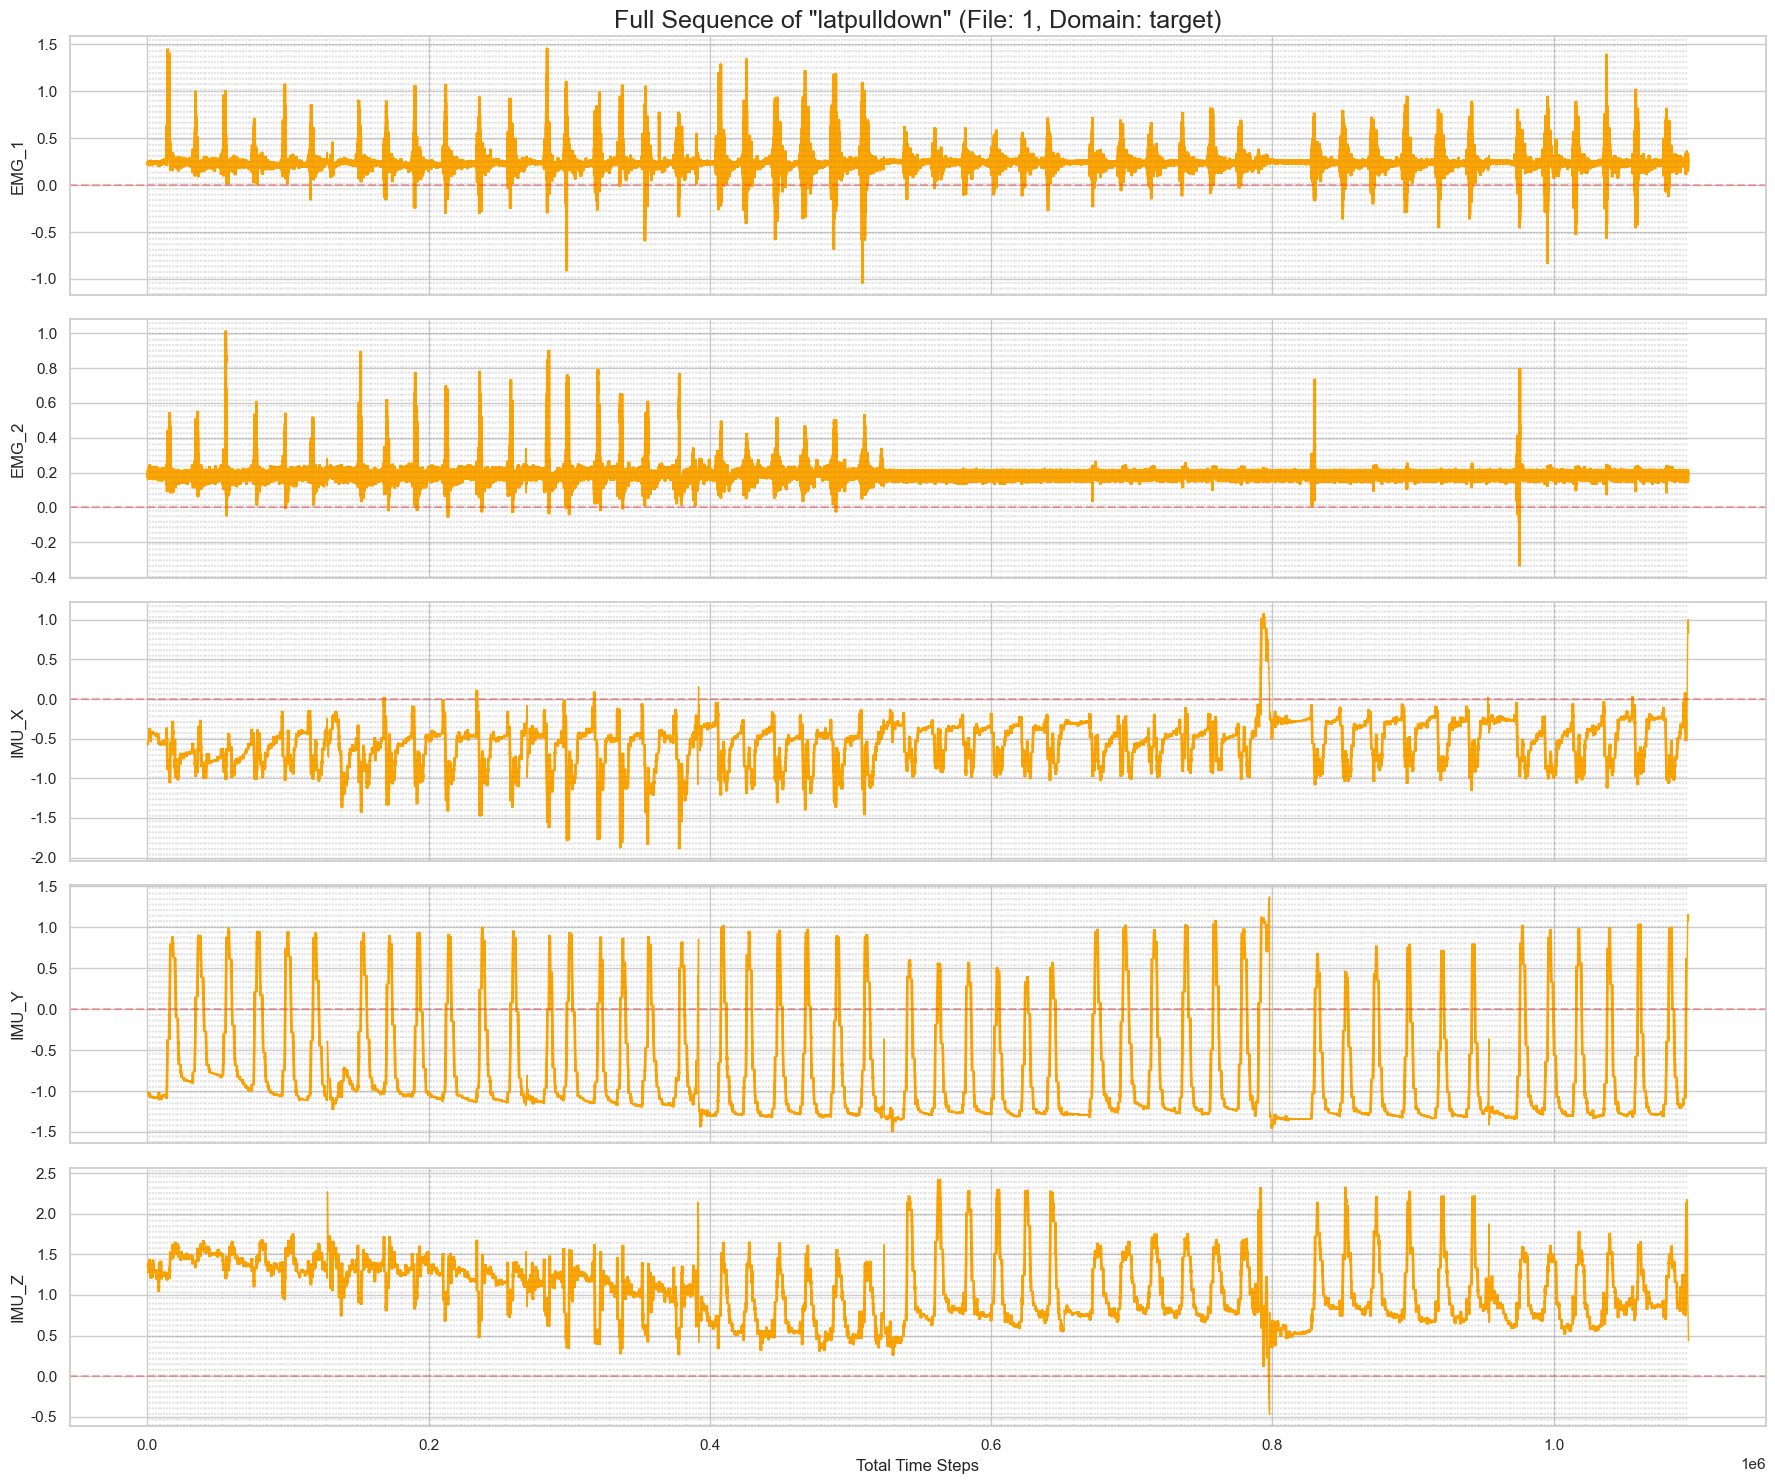

In [ ]:
# 'preprocessed_data' 폴더 안에 이 파일들이 있는지 확인해보세요!
print("식별자(Subject/File info) 로딩 중...")

sub_src_path = os.path.join(data_dir, 'sub_source.npy')
sub_tgt_path = os.path.join(data_dir, 'sub_target.npy')

# 파일이 있다면 로드합니다.
if os.path.exists(sub_src_path) and os.path.exists(sub_tgt_path):
    sub_src = np.load(sub_src_path, allow_pickle=True)
    sub_tgt = np.load(sub_tgt_path, allow_pickle=True)
    print(f"✅ 식별자 로드 완료: Source({len(sub_src)}개), Target({len(sub_tgt)}개)")
else:
    # ⚠️ 만약 파일이 없다면! (전처리 때 저장을 안 하셨다면) 
    # 아래 코드로 임시 변수를 만들어 에러만 피합니다. 
    # 하지만 이 경우 '전체 시퀀스'는 단순히 순서대로 이어 붙인 결과가 됩니다.
    print("❌ 파일이 없습니다! 임시 인덱스를 생성합니다.")
    sub_src = np.array([f'src_file_{i//10}' for i in range(len(y_src))])
    sub_tgt = np.array([f'tgt_file_{i//10}' for i in range(len(y_tgt))])
def plot_full_exercise(target_class, domain='target'):
    # 1. 데이터 선택
    if domain == 'target':
        X_data = X_tgt_scaled
        y_labels = y_tgt
        sub_info = sub_tgt # 파일명 정보가 들어있는 배열
    else:
        X_data = X_src_scaled
        y_labels = y_src
        sub_info = sub_src

    # 2. 해당 클래스의 파일 하나 선택 (첫 번째 파일 기준)
    class_files = sub_info[y_labels == target_class]
    if len(class_files) == 0:
        print(f"❌ {domain} 도메인에 {target_class} 데이터가 없습니다.")
        return
    
    selected_file = np.unique(class_files)[0] # 첫 번째 파일명 추출
    
    # 3. 해당 파일에 속하는 모든 윈도우 추출 및 이어 붙이기
    # 파일명과 클래스가 모두 일치하는 인덱스 추출
    indices = np.where((sub_info == selected_file) & (y_labels == target_class))[0]
    
    # 윈도우들을 시간 순서대로 이어 붙임 (N, 2000, 5) -> (N*2000, 5)
    full_signal = np.concatenate(X_data[indices], axis=0)
    
    # 4. 시각화
    channel_names = ['EMG_1', 'EMG_2', 'IMU_X', 'IMU_Y', 'IMU_Z']
    fig, axes = plt.subplots(5, 1, figsize=(18, 15), sharex=True)
    
    time_steps = np.arange(len(full_signal))
    
    for i in range(5):
        axes[i].plot(time_steps, full_signal[:, i], color='orange' if domain=='target' else 'blue', linewidth=1)
        axes[i].set_ylabel(channel_names[i], fontsize=12)
        axes[i].axhline(0, color='red', linestyle='--', alpha=0.3)
        
        # 윈도우 경계선 표시 (어디서 윈도우가 갈리는지 확인용)
        for boundary in range(2000, len(full_signal), 2000):
            axes[i].axvline(boundary, color='gray', linestyle=':', alpha=0.2)

    axes[0].set_title(f'Full Sequence of "{target_class}" (File: {selected_file}, Domain: {domain})', fontsize=18)
    axes[-1].set_xlabel('Total Time Steps', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_full_exercise('latpulldown', domain='target')

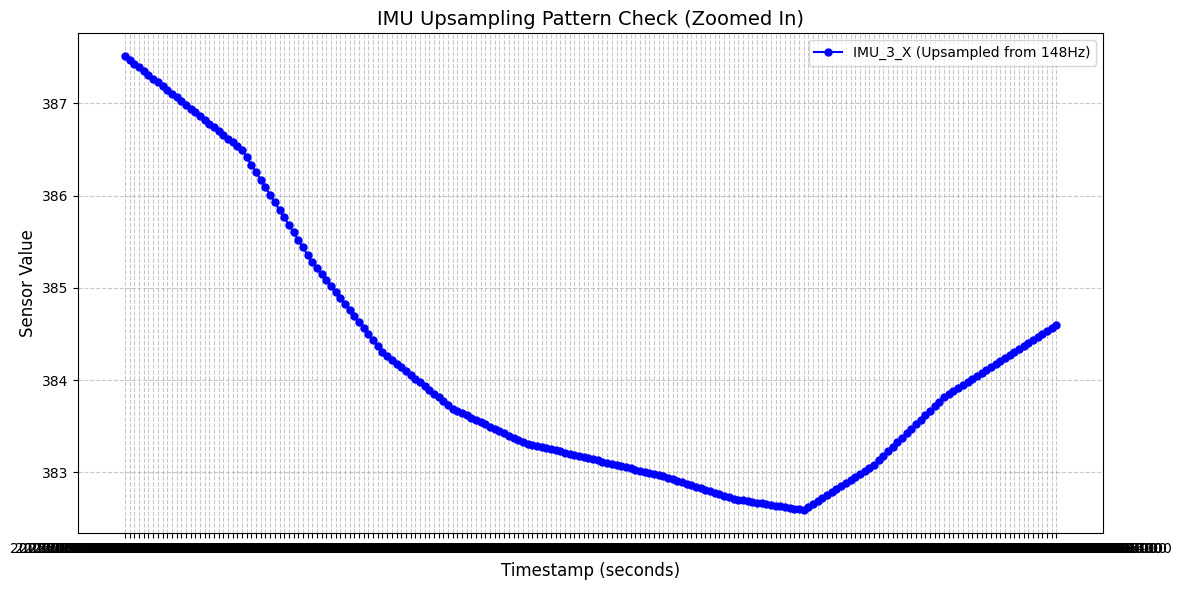

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# data1 데이터프레임이 이미 로드되어 있다고 가정합니다.

# 1. 움직임이 활발한 구간 선택 
# (이미지의 처음 부분은 IMU가 0.0이므로, 동작이 한창 진행 중인 임의의 중간 인덱스를 슬라이싱합니다)
start_idx = 50000 
end_idx = start_idx + 200  # 약 0.1초 정도의 아주 짧은 구간 (1926Hz 기준 200샘플)

sample_data = data1.iloc[start_idx:end_idx]

# 2. 시각화
plt.figure(figsize=(12, 6))

# IMU 3개 채널 중 하나(예: X축)와 EMG 채널 하나를 비교를 위해 그립니다.
plt.plot(sample_data['timestamp'], sample_data['IMU_3_X'], 
         marker='o', linestyle='-', markersize=5, linewidth=1.5, 
         label='IMU_3_X (Upsampled from 148Hz)', color='blue')

plt.title('IMU Upsampling Pattern Check (Zoomed In)', fontsize=14)
plt.xlabel('Timestamp (seconds)', fontsize=12)
plt.ylabel('Sensor Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()